# Demonstration of theta-restriction in `mhn`

This demo illustrates the usage of the 'set_restriction' method in the Optimizer class

### Prerequisites 

This notebook assumes the usage of the local mhn-implementation (accessible via `pip install -e .`)

### Preparations
The following code largely matches the procedure presented in the normal mhn-demo `demo.ipynb`.
For simplicity's sake we don't make use of cross-validation here.

In [1]:
# preparations as in 'demo.ipynb' (excluding cross-validation)

import mhn
from mhn.optimizers import Optimizer
import pandas as pd
import random
import numpy as np
input = pd.read_csv('LUAD_n12.csv')
n=len(input.columns)

input_subset = input.sample(n=500, random_state=6)
opt = Optimizer()
opt.load_data_matrix(input_subset)
opt.set_penalty(opt.Penalty.L1)
opt_lam=1.0/len(input_subset)


c:\Users\michi\Uni\SHK_Spang\learnmhn\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Restricting theta during training

Using the `set_restriction` method requires you to specify a restriction mask consisting of 0s and 1s. This is a matrix matching the shape of theta. 

 1 means this entry will be subject to changes during training (normal behavior)
 
 0 means this entry will remain unaltered during training

In [2]:
#restriction_mask=np.eye(n+1,n)
restriction_mask=np.ones((n+1,n))   #as we are using oMHN by default, the matrix shape needs to be ((n+1)xn)
restriction_mask[:,4:8]=0

np.fill_diagonal(restriction_mask,1)    #make sure diagonal entries (=baserates) are not getting restricted
restriction_mask[-1]=1                #make sure bottom row (=observation rates) are not getting restricted
opt.set_restriction(restriction_mask=restriction_mask)

After setting a restriction the training procedure can be continued as usual..
To indicate the restricted theta entries in the resulting MHN's plot you may use the `overlay_restriction_mask` argument of the `plot` method.

Imposing restriction on theta during training...
[[1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 1. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 1. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]


(<matplotlib.image.AxesImage at 0x1f667c55c10>,
 <matplotlib.colorbar.Colorbar at 0x1f667cc60d0>)

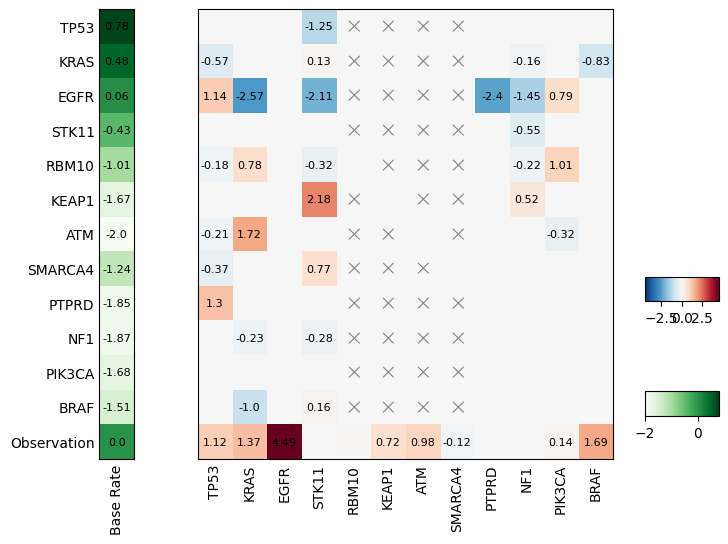

In [3]:
opt.train(lam=opt_lam)
opt.result.plot(overlay_restriction_mask=restriction_mask)

## Restrictions for non-default init_theta
You are able to restrict log-theta entries to take on arbitrary values by setting `init_theta`. In the following we show an example of forcing 'ATM' to have a strong negative effect on 'EGFR'. 

Imposing restriction on theta during training...
[[1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 1. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 1. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]


(<matplotlib.image.AxesImage at 0x1f66afcdc50>,
 <matplotlib.colorbar.Colorbar at 0x1f66c71bf90>)

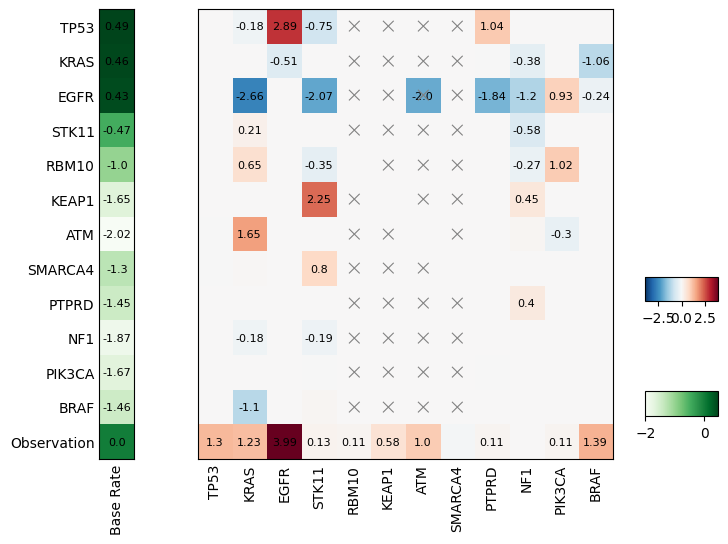

In [ ]:
#preparations
opt2 = Optimizer()
opt2.load_data_matrix(input_subset)
opt2.set_penalty(opt2.Penalty.L1)

#setting init_theta
init_theta=np.zeros((n+1,n))
init_theta[2,6]=-2              #entry of (EGFR,ATM)
opt2.set_init_theta(init_theta)

#setting restriction
opt2.set_restriction(restriction_mask)
opt2.train(opt_lam)
opt2.result.plot(overlay_restriction_mask=restriction_mask)
